# Week 10: Fixed Effects Models

**QM 2023 — Statistics II / Data Analytics**
**Spring 2026 | University of Tulsa**

---

## What You Will Learn

By the end of this demo, you will be able to:

1. **Explain** why pooled OLS is biased when unobserved entity characteristics exist
2. **Distinguish** between "within" and "between" variation in panel data
3. **Estimate** Entity Fixed Effects models using `linearmodels.PanelOLS`
4. **Estimate** Two-Way Fixed Effects models (entity + time effects)
5. **Compare** coefficients across Pooled OLS, Entity FE, and Two-Way FE specifications
6. **Interpret** the F-test for joint significance of fixed effects
7. **Explain** why R-squared may drop when moving from Pooled OLS to Fixed Effects

---

### The Big Idea

Last week, we learned how to structure **panel data** — the same entities observed over time. This week, we use that structure to solve a fundamental problem in causal inference: **omitted variable bias**.

The key insight: if unobserved characteristics (like management quality or brand value) are correlated with both our predictors and our outcome, then pooled OLS gives us **biased** coefficients. Fixed Effects solves this by giving each entity its own intercept, effectively "controlling for" everything that is constant within an entity over time.

$$Y_{it} = \beta X_{it} + \alpha_i + \epsilon_{it}$$

where $\alpha_i$ absorbs all time-invariant characteristics of entity $i$.

---

## Section 1: Setup and Data Loading

We need these libraries:

- **pandas / numpy**: Data manipulation
- **matplotlib**: Visualizations
- **statsmodels**: Pooled OLS estimation
- **linearmodels**: Panel data models (PanelOLS for Fixed Effects)

In [1]:
# Standard data science imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Panel data models
from linearmodels.panel import PanelOLS

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Plot style settings for consistent, beginner-friendly visuals
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 10

# Consistent color palette used throughout this notebook
COLOR_POOLED = '#c44e52'       # Red for Pooled OLS (the "biased" model)
COLOR_ENTITY_FE = '#4c72b0'    # Blue for Entity FE
COLOR_TWOWAY_FE = '#55a868'    # Green for Two-Way FE
COLOR_NEUTRAL = '#6c757d'      # Gray for neutral elements
COLOR_ACCENT = '#8172b3'       # Purple for accents

# Path to demo output folder (for saving figures)
from pathlib import Path
DEMO_DIR = Path('.')  # Figures saved alongside this notebook

print("Imports successful!")
print(f"  pandas {pd.__version__}, numpy {np.__version__}")

Imports successful!
  pandas 3.0.2, numpy 2.4.4


### Load the REIT Panel Data

We use real REIT (Real Estate Investment Trust) data. Each row is one REIT in one year. The key variables we will focus on:

| Variable | Description |
|----------|-------------|
| `permno` | Unique REIT identifier (entity) |
| `year` | Calendar year (time) |
| `ret12` | Annual stock return (our **outcome**) |
| `lnmcap` | Log of market capitalization (a **predictor** — firm size) |
| `beta` | Market risk exposure (a **predictor**) |
| `bookleverage` | Financial leverage ratio (a **predictor**) |

In [2]:
# Load the REIT panel data from this workspace
reit_data_path = Path('data/REIT_sample_annual_2004_2024.csv')

if not reit_data_path.exists():
    raise FileNotFoundError('Could not find data/REIT_sample_annual_2004_2024.csv in this repository.')

df_raw = pd.read_csv(reit_data_path)

print(f"Loaded data from: {reit_data_path.resolve()}")
print(f"Raw data shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
print(f"\nFirst 5 rows:")
df_raw.head()

Loaded data from: /workspaces/qm2023-week10-fixed-effects-demos/data/REIT_sample_annual_2004_2024.csv
Raw data shape: 2630 rows x 26 columns

First 5 rows:


,year,permno,ticker,comnam,age,div12m_me,ffo_at_reit,ffo_yld_reit,beta,realizedvol,...,debt_at,bookleverage,assetgrowth,dolvol,sale_me,ebitda_me,cash_at,net_income,book_equity,ret12
0,2004,10952,UNII,UNI INVEST U S LTD,228.0,0.031295,0.003399,0.000006,-0.239846,0.013900,...,0.576852,18.412499,0.001307,-2.419381e+07,0.143712,0.016505,0.024934,-14.91025,112.97100,0.228164
1,2005,10952,UNII,UNI INVEST U S LTD,240.0,0.053209,0.011787,0.000018,-0.493774,0.013702,...,0.452059,2.711135,0.000986,-4.591102e+07,0.171199,0.023514,0.023313,1.20075,176.84325,0.048434
2,2006,10952,UNII,UNI INVEST U S LTD,252.0,0.050072,0.010122,0.000017,-0.502520,0.010579,...,0.504948,3.186358,0.000738,-6.128505e+07,0.169909,0.022763,0.020839,12.82700,313.81975,0.197044
3,2007,10952,UNII,UNI INVEST U S LTD,264.0,0.058712,0.011058,0.000022,0.203412,0.015871,...,0.492048,2.865354,0.000506,-7.749376e+07,0.213961,0.033467,0.022175,16.26450,454.59025,-0.314575
4,2008,10952,UNII,UNI INVEST U S LTD,276.0,0.089553,0.009226,0.000031,0.482287,0.035310,...,0.550419,3.048231,0.000267,-9.240888e+07,0.358788,0.046434,0.020820,20.70775,465.93200,-0.234077


In [3]:
# Select the columns we need and drop rows with missing values
columns_to_keep = ['permno', 'year', 'ticker', 'comnam', 'ret12', 'lnmcap', 'beta', 'bookleverage']
df = df_raw[columns_to_keep].dropna().copy()

# Check the panel dimensions
n_reits = df['permno'].nunique()       # Number of unique REITs (entities)
n_years = df['year'].nunique()          # Number of unique years (time periods)
n_observations = len(df)               # Total observations

print(f"Panel Dimensions:")
print(f"  N (unique REITs):    {n_reits}")
print(f"  T (unique years):    {n_years}")
print(f"  Total observations:  {n_observations}")
print(f"  Year range:          {df['year'].min()} - {df['year'].max()}")
print(f"\nDescriptive statistics for key variables:")
df[['ret12', 'lnmcap', 'beta', 'bookleverage']].describe().round(3)

Panel Dimensions:
  N (unique REITs):    238
  T (unique years):    21
  Total observations:  2387
  Year range:          2004 - 2024

Descriptive statistics for key variables:


,ret12,lnmcap,beta,bookleverage
count,2387.000,2387.000,2387.000,2387.000
mean,0.105,14.383,0.829,3.246
std,0.288,1.669,0.551,31.461
min,-0.604,9.244,-0.574,-884.697
25%,-0.070,13.500,0.455,2.014
50%,0.106,14.520,0.744,2.546
75%,0.273,15.421,1.092,3.623
max,1.023,18.583,3.586,496.081


Saved: fe_demo_reits_per_year.png


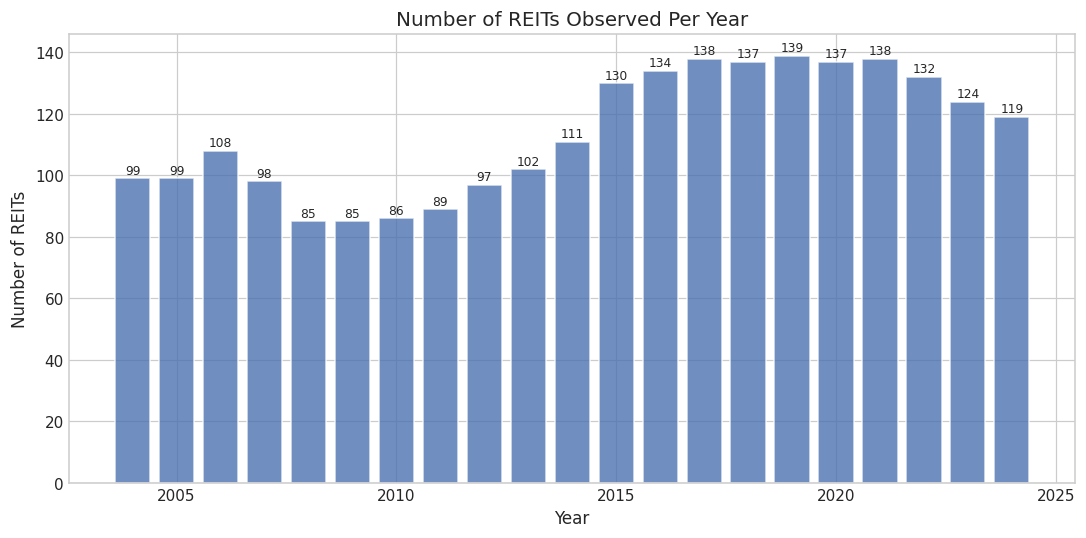

In [4]:
# Chart 1: Number of REITs observed per year (bar chart)
reits_per_year = df.groupby('year')['permno'].nunique()  # Count unique REITs in each year

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(reits_per_year.index, reits_per_year.values, color=COLOR_ENTITY_FE, alpha=0.8, edgecolor='white')
ax.set_xlabel('Year')
ax.set_ylabel('Number of REITs')
ax.set_title('Number of REITs Observed Per Year')

# Add count labels on top of each bar
for year_val, count_val in zip(reits_per_year.index, reits_per_year.values):
    ax.text(year_val, count_val + 0.5, str(count_val), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(DEMO_DIR / 'fe_demo_reits_per_year.png', dpi=150, bbox_inches='tight')
print("Saved: fe_demo_reits_per_year.png")
plt.show()

### Interpretation: Panel Structure

This is an **unbalanced panel** — the number of REITs varies from year to year because firms enter and exit the sample. That is completely normal in real-world data. The important thing is that we observe *the same entities* across *multiple time periods*, which gives us the "within-entity" variation we need for Fixed Effects.

---

## Section 2: Visualizing the Problem — Omitted Variable Bias

Before we estimate any models, let's **see** the problem that Fixed Effects is designed to solve.

**The question:** Does firm size (`lnmcap`) predict annual returns (`ret12`)?

If we just throw all the data into a scatter plot (pooling across all REITs), we are mixing up two very different sources of variation:

1. **Between-entity variation:** Some REITs are systematically larger than others
2. **Within-entity variation:** A given REIT's size changes over time

Pooled OLS combines both. Fixed Effects uses only #2.

Saved: fe_demo_pooled_scatter.png


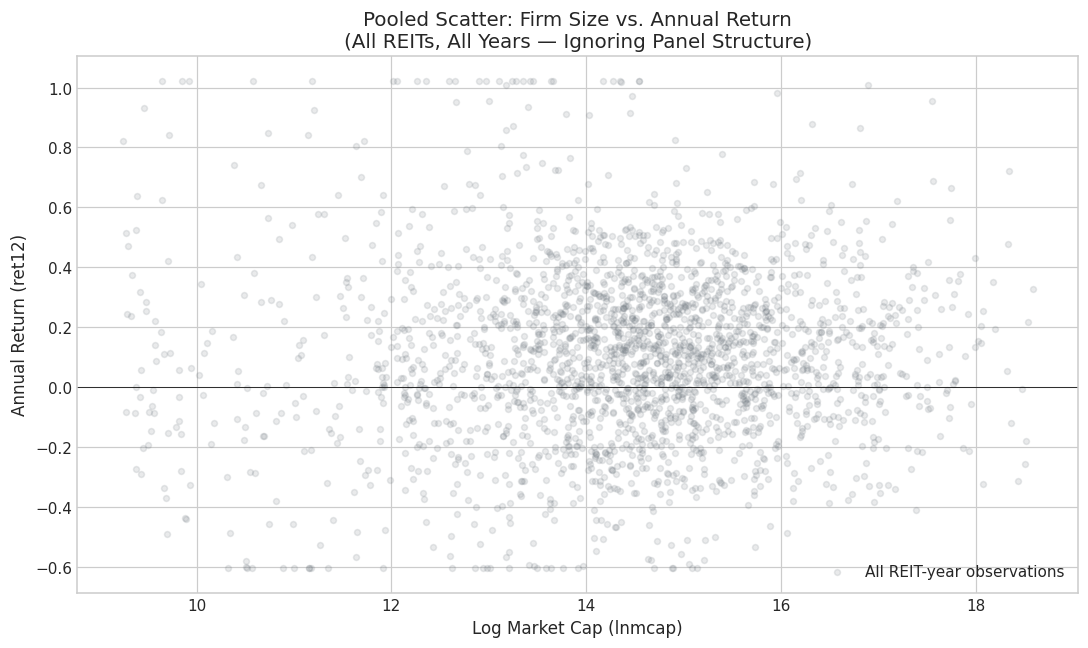

In [5]:
# Chart 2: Pooled scatter plot — lnmcap vs ret12 (all REITs lumped together)
annual_return = df['ret12']          # Outcome: annual stock return
log_market_cap = df['lnmcap']       # Predictor: log market capitalization

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(log_market_cap, annual_return, alpha=0.15, s=15, color=COLOR_NEUTRAL, label='All REIT-year observations')
ax.set_xlabel('Log Market Cap (lnmcap)')
ax.set_ylabel('Annual Return (ret12)')
ax.set_title('Pooled Scatter: Firm Size vs. Annual Return\n(All REITs, All Years — Ignoring Panel Structure)')
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='-')

plt.tight_layout()
plt.savefig(DEMO_DIR / 'fe_demo_pooled_scatter.png', dpi=150, bbox_inches='tight')
print("Saved: fe_demo_pooled_scatter.png")
plt.show()

That scatter plot treats every observation as independent. But we know that the same REIT appears multiple times! Let's highlight a few specific REITs to see the **entity heterogeneity** — different REITs have different baseline levels.

Saved: fe_demo_entity_heterogeneity.png


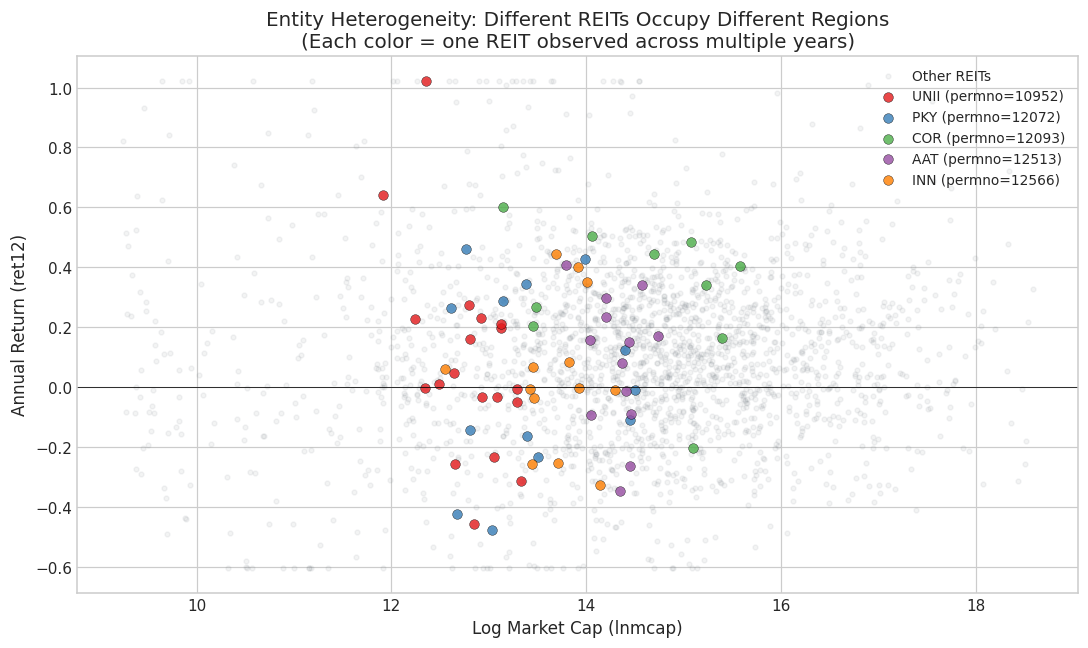

In [6]:
# Chart 3: Highlight a few specific REITs to show entity heterogeneity
# Pick 5 REITs that appear in many years (so we can see their trajectories)
reit_year_counts = df.groupby('permno')['year'].count()               # How many years each REIT appears
reits_with_many_years = reit_year_counts[reit_year_counts >= 10].index  # REITs with 10+ observations
highlight_reits = list(reits_with_many_years[:5])                      # Pick the first 5

# Get ticker names for the legend
reit_tickers = df[df['permno'].isin(highlight_reits)].groupby('permno')['ticker'].first()

# Color palette for highlighted REITs
highlight_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

fig, ax = plt.subplots(figsize=(10, 6))

# Plot all data points in gray (background)
ax.scatter(df['lnmcap'], df['ret12'], alpha=0.08, s=10, color=COLOR_NEUTRAL, label='Other REITs')

# Overlay the highlighted REITs in color
for i, reit_id in enumerate(highlight_reits):
    reit_subset = df[df['permno'] == reit_id]                           # Filter to this REIT
    reit_lnmcap = reit_subset['lnmcap']                                # This REIT's log market cap
    reit_return = reit_subset['ret12']                                  # This REIT's annual return
    reit_ticker = reit_tickers[reit_id]                                 # This REIT's ticker symbol
    ax.scatter(reit_lnmcap, reit_return, alpha=0.8, s=40, 
               color=highlight_colors[i], label=f'{reit_ticker} (permno={reit_id})', 
               edgecolors='black', linewidth=0.3)

ax.set_xlabel('Log Market Cap (lnmcap)')
ax.set_ylabel('Annual Return (ret12)')
ax.set_title('Entity Heterogeneity: Different REITs Occupy Different Regions\n(Each color = one REIT observed across multiple years)')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='-')

plt.tight_layout()
plt.savefig(DEMO_DIR / 'fe_demo_entity_heterogeneity.png', dpi=150, bbox_inches='tight')
print("Saved: fe_demo_entity_heterogeneity.png")
plt.show()

### Alternative View: Color by Year

The next chart keeps the same axes as the entity-heterogeneity plot, but colors each observation by calendar year instead of by REIT. This helps show whether the cloud shifts over time rather than across firms.

Saved: fe_demo_year_colored_scatter.png


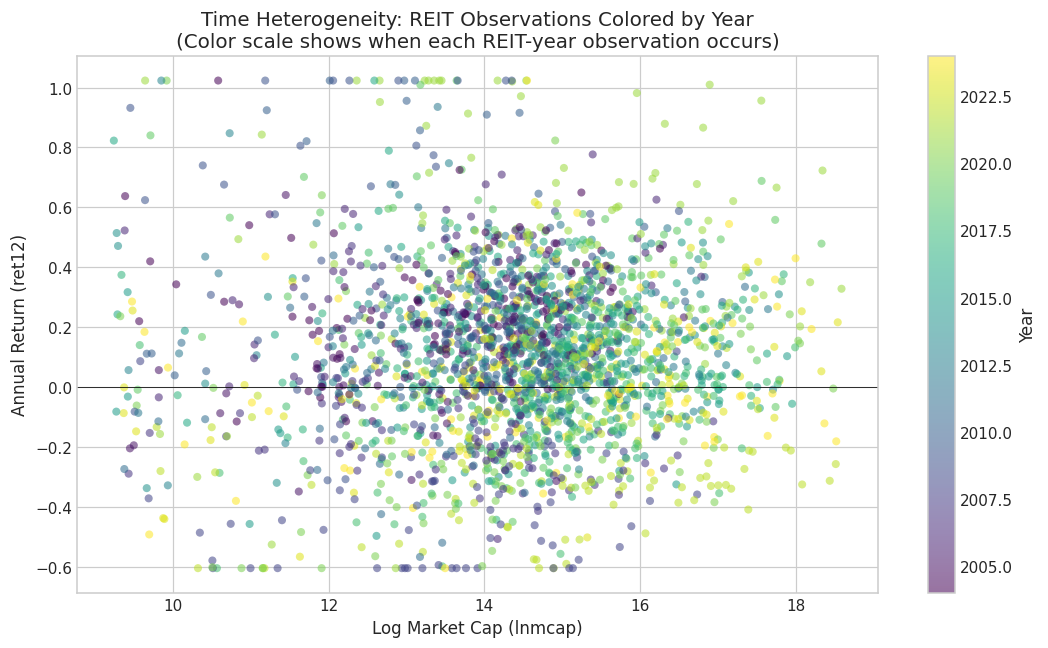

In [7]:
# Chart 3b: Same scatter, but color observations by year instead of by firm
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df['lnmcap'],
    df['ret12'],
    c=df['year'],
    cmap='viridis',
    alpha=0.55,
    s=28,
    edgecolors='none'
 )

colorbar = plt.colorbar(scatter, ax=ax)
colorbar.set_label('Year')

ax.set_xlabel('Log Market Cap (lnmcap)')
ax.set_ylabel('Annual Return (ret12)')
ax.set_title('Time Heterogeneity: REIT Observations Colored by Year\n(Color scale shows when each REIT-year observation occurs)')
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='-')

plt.tight_layout()
plt.savefig(DEMO_DIR / 'fe_demo_year_colored_scatter.png', dpi=150, bbox_inches='tight')
print("Saved: fe_demo_year_colored_scatter.png")
plt.show()

### What do you see?

Each colored cluster represents **one REIT** observed across multiple years. Notice how different REITs "live" in different parts of the plot — some are consistently large, others small; some have higher average returns, others lower.

This is **entity heterogeneity**: unobserved REIT-specific characteristics (management quality, property portfolio, geographic focus) that affect both size and returns.

**The problem:** If we run a single regression line through all the gray dots, we are mixing up "REITs that are bigger tend to have different returns" (between variation) with "when a REIT gets bigger, its return changes" (within variation). These are **different questions** and may have **different answers**.

Saved: fe_demo_spaghetti.png


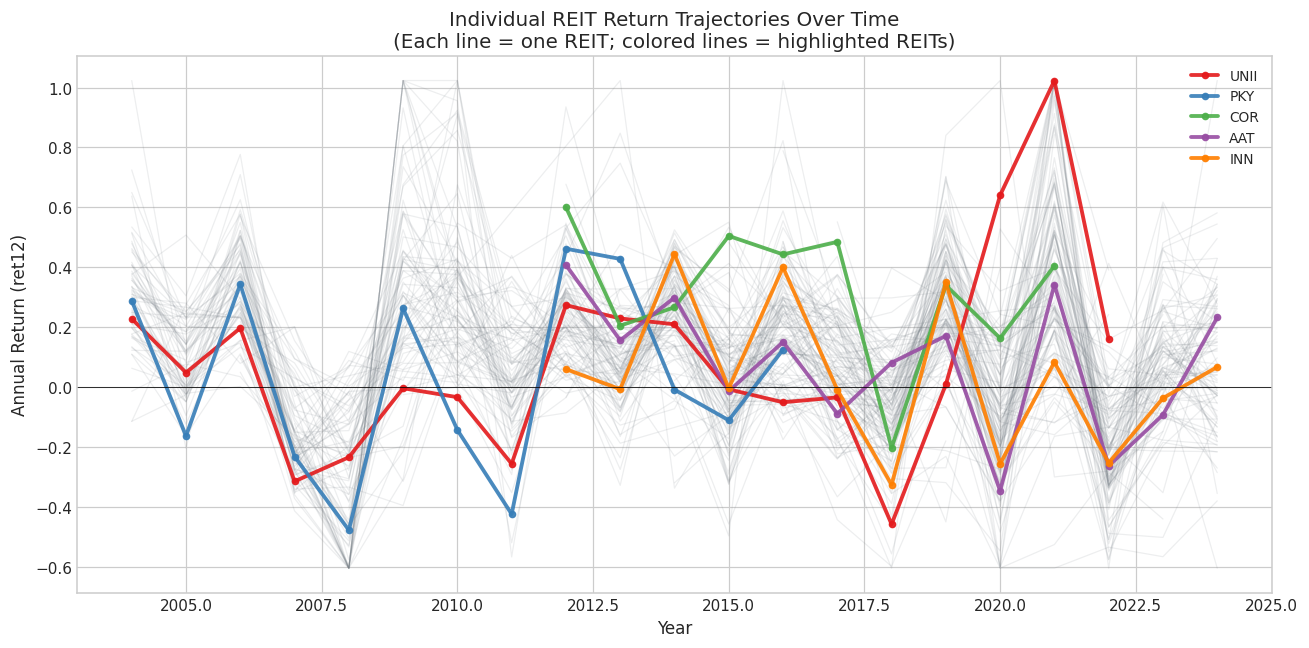

In [8]:
# Chart 4: Spaghetti plot — individual REIT return trajectories over time
# This shows how different REITs follow different paths

fig, ax = plt.subplots(figsize=(12, 6))

# Plot trajectories for REITs with at least 8 years of data (for readability)
reits_with_history = df.groupby('permno').filter(lambda x: len(x) >= 8)['permno'].unique()

# Plot each REIT as a faint line
for reit_id in reits_with_history:
    reit_subset = df[df['permno'] == reit_id].sort_values('year')
    ax.plot(reit_subset['year'], reit_subset['ret12'], alpha=0.12, linewidth=0.8, color=COLOR_NEUTRAL)

# Overlay the 5 highlighted REITs in bold colors
for i, reit_id in enumerate(highlight_reits):
    reit_subset = df[df['permno'] == reit_id].sort_values('year')
    reit_ticker = reit_tickers[reit_id]
    ax.plot(reit_subset['year'], reit_subset['ret12'], alpha=0.9, linewidth=2.5, 
            color=highlight_colors[i], label=f'{reit_ticker}', marker='o', markersize=4)

ax.set_xlabel('Year')
ax.set_ylabel('Annual Return (ret12)')
ax.set_title('Individual REIT Return Trajectories Over Time\n(Each line = one REIT; colored lines = highlighted REITs)')
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='-')

plt.tight_layout()
plt.savefig(DEMO_DIR / 'fe_demo_spaghetti.png', dpi=150, bbox_inches='tight')
print("Saved: fe_demo_spaghetti.png")
plt.show()

---

## Section 3: Within vs. Between Variation

This is the **core concept** of Fixed Effects. All variation in our data can be split into two parts:

- **Between variation**: How does REIT A's *average* differ from REIT B's *average*? (Cross-sectional differences)
- **Within variation**: How does REIT A deviate from its *own* average over time? (Temporal changes for the same entity)

**Fixed Effects throws away the between variation and uses only within variation.** Why? Because between-entity differences might be driven by unobserved characteristics (management quality, location, etc.) that confound our estimate.

In [9]:
# Calculate group means for each REIT (the "between" component)
reit_means = df.groupby('permno')[['ret12', 'lnmcap', 'beta', 'bookleverage']].mean()
reit_means.columns = ['mean_ret12', 'mean_lnmcap', 'mean_beta', 'mean_bookleverage']

# Merge the group means back onto the original data
df = df.merge(reit_means, left_on='permno', right_index=True, how='left')

# Calculate the "within" component: deviation from group mean
df['within_ret12'] = df['ret12'] - df['mean_ret12']           # How much this year's return deviates from the REIT's average
df['within_lnmcap'] = df['lnmcap'] - df['mean_lnmcap']       # How much this year's size deviates from the REIT's average

print("Variation decomposition for log market cap (lnmcap):")
total_var_lnmcap = df['lnmcap'].var()                          # Total variance
between_var_lnmcap = df['mean_lnmcap'].var()                   # Between-entity variance (variance of entity means)
within_var_lnmcap = df['within_lnmcap'].var()                  # Within-entity variance (variance of deviations)

print(f"  Total variance:    {total_var_lnmcap:.4f}")
print(f"  Between (across REITs): {between_var_lnmcap:.4f}  ({between_var_lnmcap/total_var_lnmcap*100:.1f}%)")
print(f"  Within (over time):     {within_var_lnmcap:.4f}  ({within_var_lnmcap/total_var_lnmcap*100:.1f}%)")

print(f"\nVariation decomposition for annual return (ret12):")
total_var_ret12 = df['ret12'].var()
between_var_ret12 = df['mean_ret12'].var()
within_var_ret12 = df['within_ret12'].var()

print(f"  Total variance:    {total_var_ret12:.4f}")
print(f"  Between (across REITs): {between_var_ret12:.4f}  ({between_var_ret12/total_var_ret12*100:.1f}%)")
print(f"  Within (over time):     {within_var_ret12:.4f}  ({within_var_ret12/total_var_ret12*100:.1f}%)")

Variation decomposition for log market cap (lnmcap):
  Total variance:    2.7853
  Between (across REITs): 2.3692  (85.1%)
  Within (over time):     0.4162  (14.9%)

Variation decomposition for annual return (ret12):
  Total variance:    0.0828
  Between (across REITs): 0.0064  (7.7%)
  Within (over time):     0.0764  (92.3%)


Saved: fe_demo_within_between.png


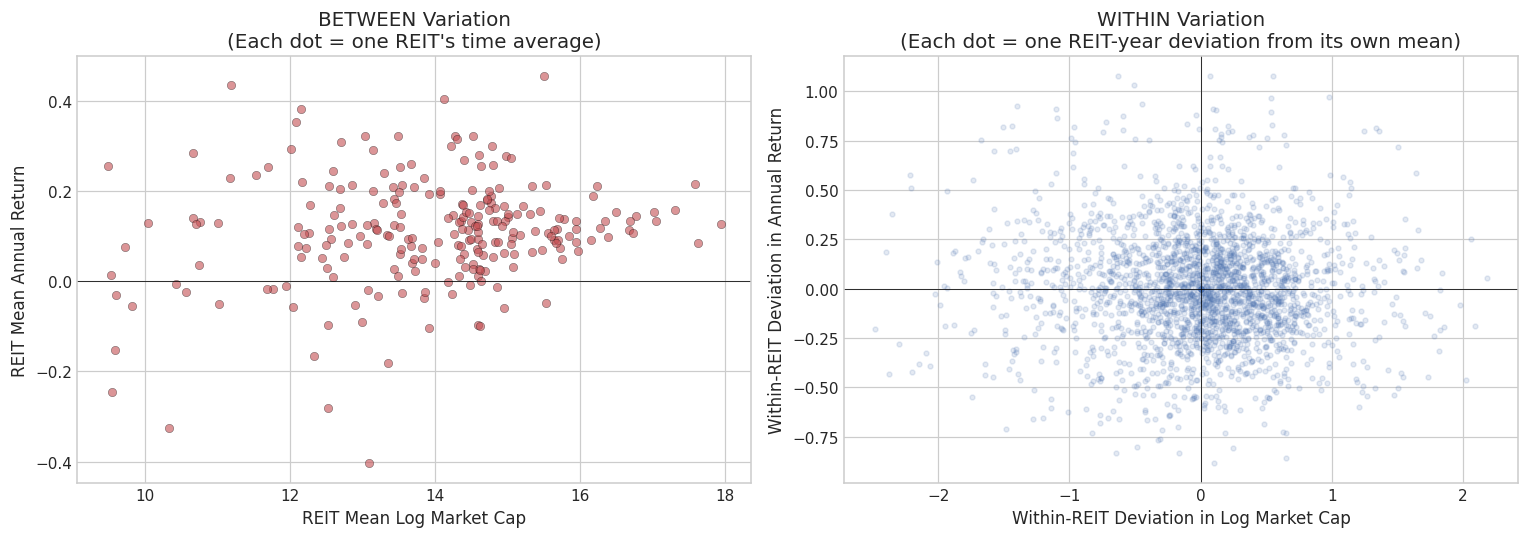

In [10]:
# Chart 5: Between variation (scatter of REIT means) vs. Within variation (deviations)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Between variation — each dot is one REIT's average
between_lnmcap = reit_means['mean_lnmcap']        # Each REIT's average log market cap
between_ret12 = reit_means['mean_ret12']            # Each REIT's average annual return

axes[0].scatter(between_lnmcap, between_ret12, alpha=0.6, s=30, color=COLOR_POOLED, edgecolors='black', linewidth=0.3)
axes[0].set_xlabel('REIT Mean Log Market Cap')
axes[0].set_ylabel('REIT Mean Annual Return')
axes[0].set_title('BETWEEN Variation\n(Each dot = one REIT\'s time average)')
axes[0].axhline(y=0, color='black', linewidth=0.5, linestyle='-')

# Right panel: Within variation — deviations from REIT means
within_lnmcap = df['within_lnmcap']               # Deviation of lnmcap from REIT mean
within_ret12 = df['within_ret12']                   # Deviation of ret12 from REIT mean

axes[1].scatter(within_lnmcap, within_ret12, alpha=0.15, s=10, color=COLOR_ENTITY_FE)
axes[1].set_xlabel('Within-REIT Deviation in Log Market Cap')
axes[1].set_ylabel('Within-REIT Deviation in Annual Return')
axes[1].set_title('WITHIN Variation\n(Each dot = one REIT-year deviation from its own mean)')
axes[1].axhline(y=0, color='black', linewidth=0.5, linestyle='-')
axes[1].axvline(x=0, color='black', linewidth=0.5, linestyle='-')

plt.tight_layout()
plt.savefig(DEMO_DIR / 'fe_demo_within_between.png', dpi=150, bbox_inches='tight')
print("Saved: fe_demo_within_between.png")
plt.show()

### Interpretation: Within vs. Between

- **Left panel (Between):** Each dot is one REIT's time-average. The relationship here reflects *which REITs* are bigger and *which REITs* have higher returns. This mixes in all the unobserved entity characteristics.

- **Right panel (Within):** Each dot shows how a REIT-year *deviates from that REIT's own average*. The relationship here answers: "When a REIT gets bigger than its own norm, does its return also deviate?"

**Fixed Effects uses only the right panel.** By "demeaning" — subtracting each REIT's average — we remove all time-invariant confounders. This is mathematically equivalent to adding a separate intercept (dummy variable) for every REIT.

### Visualizing What an Entity Fixed Effect Does

The phrase **"entity fixed effect"** can sound abstract, but mechanically it does something very concrete: it subtracts each firm's own average level.

For firm $i$, the entity-demeaned version of a variable is:

$$x_{it} - \bar{x}_i$$

That transformation leaves the **ups and downs within a firm** intact, but removes the firm's typical baseline level. In other words, the model stops asking "which firms are bigger than other firms?" and starts asking "when this same firm moves above or below its own usual level, what happens?"

Teaching firms selected for FE visuals:
  EGP (85082)
  FR (80683)
  RLIN (77239)
  SUI (80102)
Saved: fe_demo_entity_demeaning_lines.png


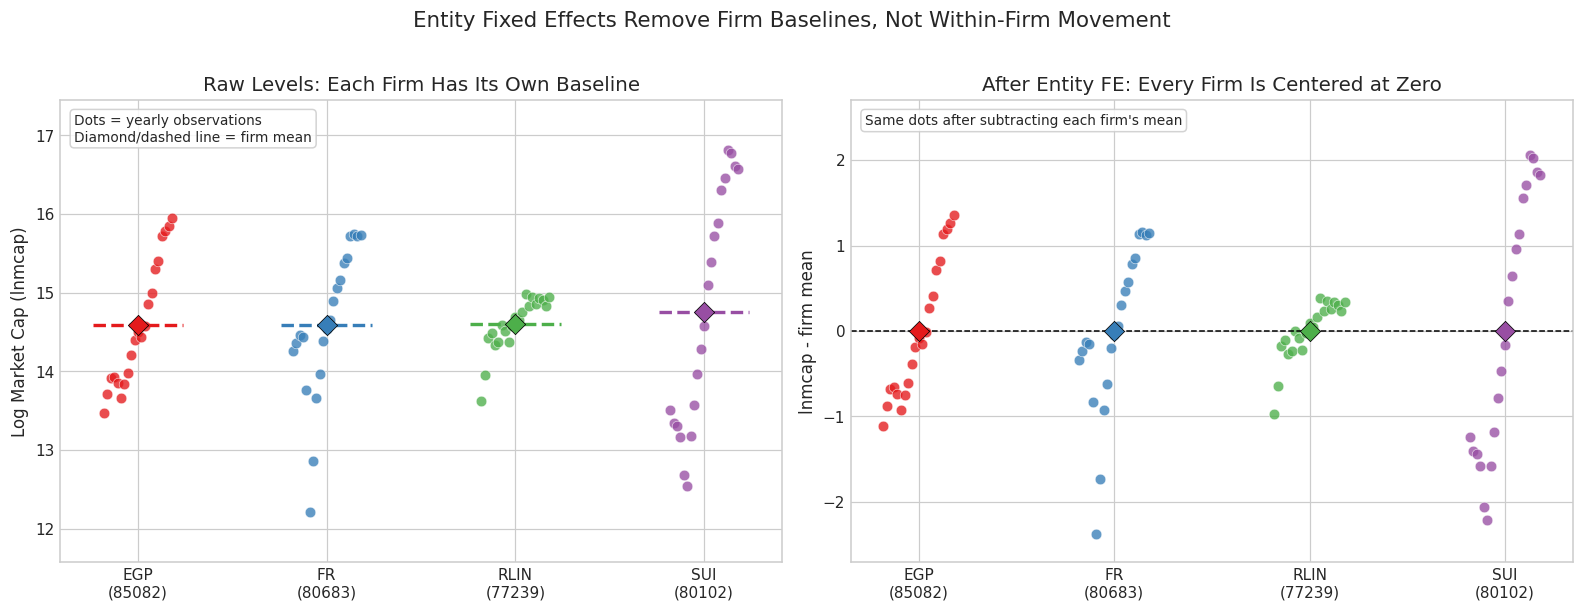

In [11]:
# Chart 5b: Entity fixed effects as firm-specific baseline removal
from itertools import combinations

firm_selection_stats = (
    df.groupby('permno')
    .agg(
        ticker=('ticker', 'first'),
        n_obs=('year', 'size'),
        mean_lnmcap=('lnmcap', 'mean'),
        sd_lnmcap=('lnmcap', 'std'),
        min_year=('year', 'min'),
        max_year=('year', 'max')
    )
    .dropna()
    .sort_values(['n_obs', 'sd_lnmcap'], ascending=[False, False])
)

candidate_stats = firm_selection_stats[
    (firm_selection_stats['n_obs'] >= 10)
    & (firm_selection_stats['sd_lnmcap'] >= firm_selection_stats['sd_lnmcap'].quantile(0.4))
    & (firm_selection_stats['mean_lnmcap'].between(
        firm_selection_stats['mean_lnmcap'].quantile(0.2),
        firm_selection_stats['mean_lnmcap'].quantile(0.8)
    ))
]

candidate_ids = candidate_stats.index.tolist()[:18]
best_combo = None
best_score = None

for combo in combinations(candidate_ids, 4):
    combo_subset = df[df['permno'].isin(combo)].copy()
    years_by_firm = [set(combo_subset.loc[combo_subset['permno'] == reit_id, 'year']) for reit_id in combo]
    common_years = sorted(set.intersection(*years_by_firm))

    if len(common_years) < 6:
        continue

    combo_means = candidate_stats.loc[list(combo), 'mean_lnmcap']
    combo_sds = candidate_stats.loc[list(combo), 'sd_lnmcap']
    mean_spread = combo_means.max() - combo_means.min()
    avg_sd = combo_sds.mean()
    score = (len(common_years) * 2.5) + avg_sd - (1.8 * mean_spread)

    if best_score is None or score > best_score:
        best_score = score
        best_combo = combo

if best_combo is None:
    entity_demo_reits = highlight_reits[:4]
else:
    entity_demo_reits = list(best_combo)

entity_demo = df[df['permno'].isin(entity_demo_reits)].copy()
entity_demo['demeaned_lnmcap'] = entity_demo['lnmcap'] - entity_demo.groupby('permno')['lnmcap'].transform('mean')

firm_mean_lnmcap = entity_demo.groupby('permno')['lnmcap'].mean()
firm_labels = (
    entity_demo.groupby('permno')['ticker'].first()
    .fillna('Unknown')
    .astype(str)
    .to_dict()
)

entity_demo_reits = firm_mean_lnmcap.sort_values().index.tolist()
display_labels = [f"{firm_labels[reit_id]}\n({reit_id})" for reit_id in entity_demo_reits]

raw_lnmcap_min = entity_demo['lnmcap'].min()
raw_lnmcap_max = entity_demo['lnmcap'].max()
raw_lnmcap_padding = max(0.2, (raw_lnmcap_max - raw_lnmcap_min) * 0.14)

demeaned_abs_max = entity_demo['demeaned_lnmcap'].abs().max()
demeaned_padding = max(0.12, demeaned_abs_max * 0.14)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))

for i, reit_id in enumerate(entity_demo_reits):
    firm_subset = entity_demo[entity_demo['permno'] == reit_id].sort_values('year').reset_index(drop=True)
    firm_color = highlight_colors[i % len(highlight_colors)]
    x_center = i + 1
    jitter = np.linspace(-0.18, 0.18, len(firm_subset))

    axes[0].scatter(
        np.full(len(firm_subset), x_center) + jitter,
        firm_subset['lnmcap'],
        color=firm_color,
        alpha=0.78,
        s=48,
        edgecolors='white',
        linewidth=0.4
    )
    axes[0].hlines(
        firm_mean_lnmcap.loc[reit_id],
        x_center - 0.24,
        x_center + 0.24,
        colors=firm_color,
        linestyles='--',
        linewidth=2.2
    )
    axes[0].scatter(
        [x_center],
        [firm_mean_lnmcap.loc[reit_id]],
        color=firm_color,
        marker='D',
        s=88,
        edgecolors='black',
        linewidth=0.5,
        zorder=5
    )

    axes[1].scatter(
        np.full(len(firm_subset), x_center) + jitter,
        firm_subset['demeaned_lnmcap'],
        color=firm_color,
        alpha=0.78,
        s=48,
        edgecolors='white',
        linewidth=0.4
    )
    axes[1].scatter(
        [x_center],
        [0],
        color=firm_color,
        marker='D',
        s=88,
        edgecolors='black',
        linewidth=0.5,
        zorder=5
    )

axes[0].set_title('Raw Levels: Each Firm Has Its Own Baseline')
axes[0].set_ylabel('Log Market Cap (lnmcap)')
axes[0].set_xticks(range(1, len(entity_demo_reits) + 1))
axes[0].set_xticklabels(display_labels)
axes[0].set_ylim(raw_lnmcap_min - raw_lnmcap_padding, raw_lnmcap_max + raw_lnmcap_padding)
axes[0].text(
    0.02,
    0.97,
    'Dots = yearly observations\nDiamond/dashed line = firm mean',
    transform=axes[0].transAxes,
    va='top',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='0.8')
)

axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('After Entity FE: Every Firm Is Centered at Zero')
axes[1].set_ylabel('lnmcap - firm mean')
axes[1].set_xticks(range(1, len(entity_demo_reits) + 1))
axes[1].set_xticklabels(display_labels)
axes[1].set_ylim(-(demeaned_abs_max + demeaned_padding), demeaned_abs_max + demeaned_padding)
axes[1].text(
    0.02,
    0.97,
    'Same dots after subtracting each firm\'s mean',
    transform=axes[1].transAxes,
    va='top',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='0.8')
)

fig.suptitle('Entity Fixed Effects Remove Firm Baselines, Not Within-Firm Movement', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(DEMO_DIR / 'fe_demo_entity_demeaning_lines.png', dpi=150, bbox_inches='tight')
print('Teaching firms selected for FE visuals:')
for reit_id in entity_demo_reits:
    print(f"  {firm_labels[reit_id]} ({reit_id})")
print('Saved: fe_demo_entity_demeaning_lines.png')
plt.show()

The left panel shows what students often miss in a pooled regression: each firm lives around a different **baseline level**. Those average levels are the entity effects. The right panel shows the same firms after subtracting each firm's own average. The fluctuations remain, but the baseline differences are gone.

That is why entity FE estimates slopes from **within-firm departures from a firm's norm**, not from persistent level differences across firms.

Saved: fe_demo_entity_demeaned_scatter.png


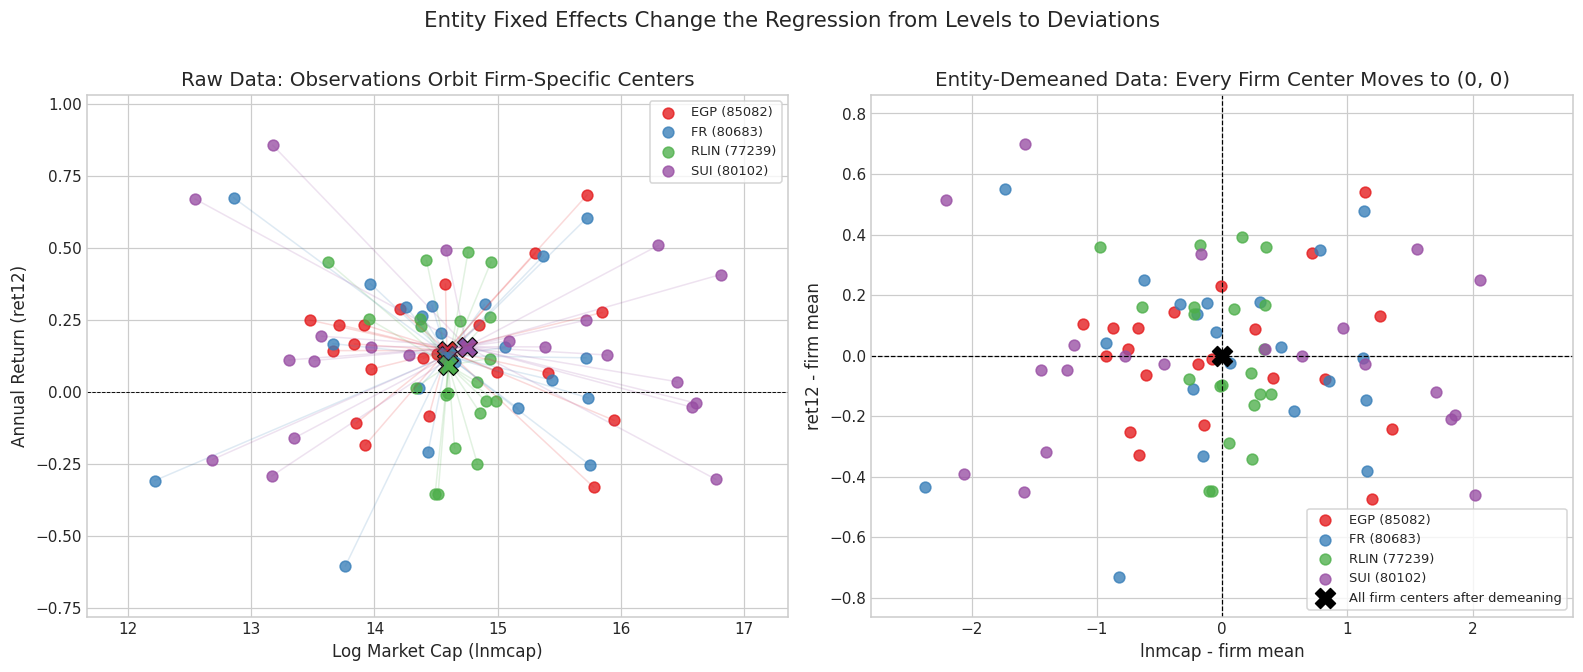

In [12]:
# Chart 5c: The same demeaning idea in scatter space
entity_scatter = df[df['permno'].isin(entity_demo_reits)].copy()
entity_scatter['demeaned_ret12'] = entity_scatter['ret12'] - entity_scatter.groupby('permno')['ret12'].transform('mean')
entity_centers = entity_scatter.groupby('permno')[['lnmcap', 'ret12']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6))

for i, reit_id in enumerate(entity_demo_reits):
    firm_subset = entity_scatter[entity_scatter['permno'] == reit_id]
    firm_color = highlight_colors[i % len(highlight_colors)]
    firm_label = f"{firm_labels[reit_id]} ({reit_id})"
    centroid_x = entity_centers.loc[reit_id, 'lnmcap']
    centroid_y = entity_centers.loc[reit_id, 'ret12']

    axes[0].scatter(
        firm_subset['lnmcap'],
        firm_subset['ret12'],
        color=firm_color,
        alpha=0.78,
        s=50,
        label=firm_label
    )
    axes[0].scatter(
        [centroid_x],
        [centroid_y],
        color=firm_color,
        marker='X',
        s=170,
        edgecolors='black',
        linewidth=0.8
    )
    for _, row in firm_subset.iterrows():
        axes[0].plot(
            [row['lnmcap'], centroid_x],
            [row['ret12'], centroid_y],
            color=firm_color,
            alpha=0.16,
            linewidth=1
        )

    axes[1].scatter(
        firm_subset['within_lnmcap'],
        firm_subset['within_ret12'],
        color=firm_color,
        alpha=0.78,
        s=50,
        label=firm_label
    )

raw_x_pad = max(0.12, (entity_scatter['lnmcap'].max() - entity_scatter['lnmcap'].min()) * 0.12)
raw_y_pad = max(0.05, (entity_scatter['ret12'].max() - entity_scatter['ret12'].min()) * 0.12)
demeaned_x_abs = entity_scatter['within_lnmcap'].abs().max()
demeaned_y_abs = entity_scatter['within_ret12'].abs().max()

axes[0].set_title('Raw Data: Observations Orbit Firm-Specific Centers')
axes[0].set_xlabel('Log Market Cap (lnmcap)')
axes[0].set_ylabel('Annual Return (ret12)')
axes[0].set_xlim(entity_scatter['lnmcap'].min() - raw_x_pad, entity_scatter['lnmcap'].max() + raw_x_pad)
axes[0].set_ylim(entity_scatter['ret12'].min() - raw_y_pad, entity_scatter['ret12'].max() + raw_y_pad)
axes[0].legend(loc='best', fontsize=8.5, frameon=True)
axes[0].axhline(0, color='black', linewidth=0.6, linestyle='--')

axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].scatter([0], [0], color='black', marker='X', s=170, label='All firm centers after demeaning')
axes[1].set_title('Entity-Demeaned Data: Every Firm Center Moves to (0, 0)')
axes[1].set_xlabel('lnmcap - firm mean')
axes[1].set_ylabel('ret12 - firm mean')
axes[1].set_xlim(-(demeaned_x_abs * 1.18), demeaned_x_abs * 1.18)
axes[1].set_ylim(-(demeaned_y_abs * 1.18), demeaned_y_abs * 1.18)
axes[1].legend(loc='best', fontsize=8.5, frameon=True)

fig.suptitle('Entity Fixed Effects Change the Regression from Levels to Deviations', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(DEMO_DIR / 'fe_demo_entity_demeaned_scatter.png', dpi=150, bbox_inches='tight')
print('Saved: fe_demo_entity_demeaned_scatter.png')
plt.show()

This second view is useful because it shows the fixed-effects transformation in the same space where the regression slope is estimated. In the raw scatter, the cloud is partly shaped by which firms are usually large or usually high-return. In the demeaned scatter, those firm centers are removed, so the slope comes only from **movement around each firm's own center**.

---

## Section 4: Model 1 — Pooled OLS

Our first model ignores the panel structure entirely. It treats every REIT-year observation as independent and estimates a single regression line:

$$\text{ret12}_{it} = \beta_0 + \beta_1 \cdot \text{lnmcap}_{it} + \beta_2 \cdot \text{beta}_{it} + \varepsilon_{it}$$

This is the "naive" approach. If unobserved REIT characteristics are correlated with our predictors, these coefficients will be **biased**.

In [13]:
# Model 1: Pooled OLS — ignores panel structure

# Define the outcome variable
y_annual_return = df['ret12']                           # Outcome: annual stock return

# Define the predictor variables
X_predictors = df[['lnmcap', 'beta']]                  # Predictors: log market cap and market beta
X_design_pooled = sm.add_constant(X_predictors)         # Add intercept column

# Estimate Pooled OLS
pooled_ols_model = sm.OLS(y_annual_return, X_design_pooled).fit()

print("=" * 60)
print("MODEL 1: POOLED OLS (ignores panel structure)")
print("=" * 60)
print(pooled_ols_model.summary().tables[1])

# Extract key results for comparison later
pooled_lnmcap_coef = pooled_ols_model.params['lnmcap']       # Coefficient on log market cap
pooled_beta_coef = pooled_ols_model.params['beta']             # Coefficient on market beta
pooled_r_squared = pooled_ols_model.rsquared                   # R-squared

print(f"\nKey Results:")
print(f"  lnmcap coefficient: {pooled_lnmcap_coef:.4f}")
print(f"  beta coefficient:   {pooled_beta_coef:.4f}")
print(f"  R-squared:          {pooled_r_squared:.4f}")

MODEL 1: POOLED OLS (ignores panel structure)
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0146      0.053      0.273      0.785      -0.090       0.119
lnmcap         0.0053      0.004      1.483      0.138      -0.002       0.012
beta           0.0181      0.011      1.683      0.093      -0.003       0.039

Key Results:
  lnmcap coefficient: 0.0053
  beta coefficient:   0.0181
  R-squared:          0.0019


Saved: fe_demo_pooled_ols_fit.png


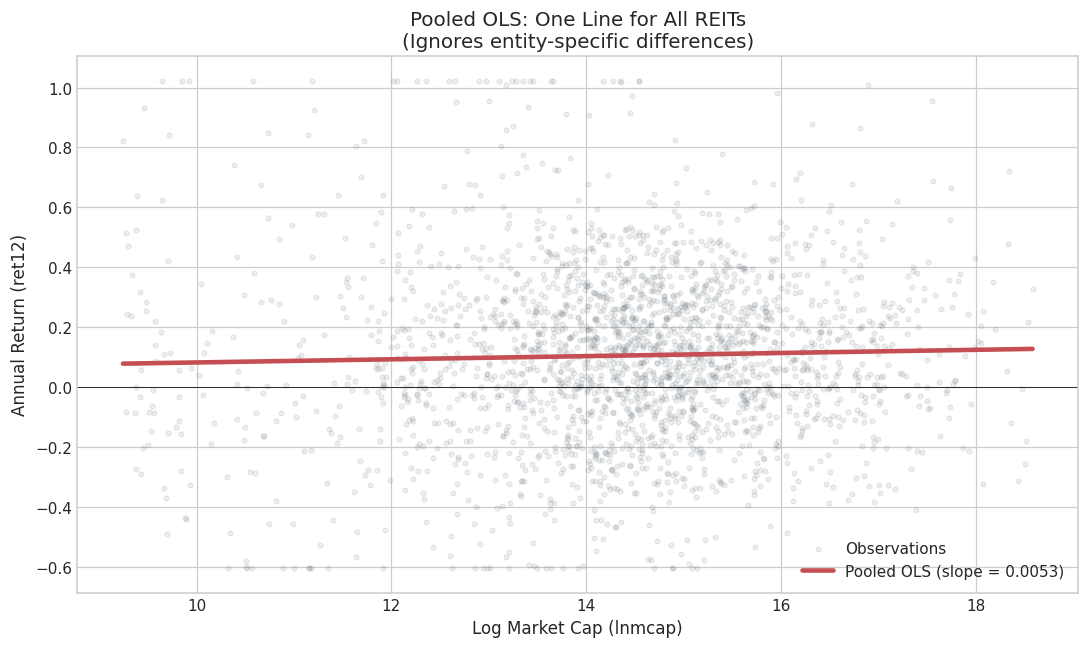

In [14]:
# Chart 6: Pooled OLS fitted line overlaid on scatter
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter all data
ax.scatter(df['lnmcap'], df['ret12'], alpha=0.12, s=10, color=COLOR_NEUTRAL, label='Observations')

# Fitted line: predict ret12 at beta=mean(beta), varying lnmcap
lnmcap_range = np.linspace(df['lnmcap'].min(), df['lnmcap'].max(), 100)
beta_mean = df['beta'].mean()                                  # Hold beta at its mean
predicted_return_pooled = (pooled_ols_model.params['const']
                           + pooled_ols_model.params['lnmcap'] * lnmcap_range
                           + pooled_ols_model.params['beta'] * beta_mean)

ax.plot(lnmcap_range, predicted_return_pooled, color=COLOR_POOLED, linewidth=3,
        label=f'Pooled OLS (slope = {pooled_lnmcap_coef:.4f})')

ax.set_xlabel('Log Market Cap (lnmcap)')
ax.set_ylabel('Annual Return (ret12)')
ax.set_title('Pooled OLS: One Line for All REITs\n(Ignores entity-specific differences)')
ax.legend(fontsize=10)
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='-')

plt.tight_layout()
plt.savefig(DEMO_DIR / 'fe_demo_pooled_ols_fit.png', dpi=150, bbox_inches='tight')
print("Saved: fe_demo_pooled_ols_fit.png")
plt.show()

### Pooled OLS Interpretation

The Pooled OLS coefficient on `lnmcap` tells us the relationship between firm size and returns **across all REITs and all years combined**. But this coefficient reflects a mixture of:

- Between-entity: "Are larger REITs different from smaller REITs?"
- Within-entity: "When a REIT grows, does its return change?"

If management quality (unobserved) is correlated with both size and returns, the Pooled OLS coefficient is **biased**. Fixed Effects will help us isolate the within-entity relationship.

---

## Section 5: Model 2 — Entity Fixed Effects (One-Way FE)

Now we add a separate intercept for each REIT. This absorbs all **time-invariant** REIT characteristics:

$$\text{ret12}_{it} = \alpha_i + \beta_1 \cdot \text{lnmcap}_{it} + \beta_2 \cdot \text{beta}_{it} + \varepsilon_{it}$$

where $\alpha_i$ is a REIT-specific intercept. We estimate this using `linearmodels.PanelOLS`.

**Critical step:** We must set a MultiIndex `(permno, year)` before calling PanelOLS.

In [15]:
# CRITICAL: Create MultiIndex for panel data
# PanelOLS requires the DataFrame to have a MultiIndex with (entity, time)
panel_df = df.set_index(['permno', 'year']).sort_index()

print("MultiIndex structure:")
print(f"  Index names:  {panel_df.index.names}")
print(f"  Index levels: {len(panel_df.index.get_level_values(0).unique())} entities x "
      f"{len(panel_df.index.get_level_values(1).unique())} time periods")
print(f"\nFirst 5 rows of panel_df:")
panel_df[['ret12', 'lnmcap', 'beta']].head()

MultiIndex structure:
  Index names:  ['permno', 'year']
  Index levels: 238 entities x 21 time periods

First 5 rows of panel_df:


ret12     lnmcap      beta
permno year                               
10952  2004  0.228164  12.241140 -0.239846
       2005  0.048434  12.645662 -0.493774
       2006  0.197044  13.129318 -0.502520
       2007 -0.314575  13.328322  0.203412
       2008 -0.234077  13.057649  0.482287

In [16]:
# Model 2: Entity Fixed Effects using PanelOLS

# Define dependent variable (outcome)
y_panel_return = panel_df['ret12']

# Define independent variables (predictors) — no constant needed, FE absorbs it
X_panel_predictors = panel_df[['lnmcap', 'beta']]

# Estimate Entity FE model
entity_fe_model = PanelOLS(y_panel_return, X_panel_predictors, entity_effects=True)
entity_fe_results = entity_fe_model.fit(cov_type='clustered', cluster_entity=True)

print("=" * 60)
print("MODEL 2: ENTITY FIXED EFFECTS")
print("=" * 60)
print(entity_fe_results.summary.tables[1])

# Extract key results
entity_fe_lnmcap_coef = entity_fe_results.params['lnmcap']
entity_fe_beta_coef = entity_fe_results.params['beta']
entity_fe_r_squared = entity_fe_results.rsquared

print(f"\nKey Results:")
print(f"  lnmcap coefficient: {entity_fe_lnmcap_coef:.4f}")
print(f"  beta coefficient:   {entity_fe_beta_coef:.4f}")
print(f"  R-squared (within): {entity_fe_r_squared:.4f}")

MODEL 2: ENTITY FIXED EFFECTS
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
lnmcap        -0.0149     0.0082    -1.8187     0.0691     -0.0309      0.0012
beta           0.0819     0.0138     5.9253     0.0000      0.0548      0.1090

Key Results:
  lnmcap coefficient: -0.0149
  beta coefficient:   0.0819
  R-squared (within): 0.0158


Saved: fe_demo_coef_comparison_2model.png


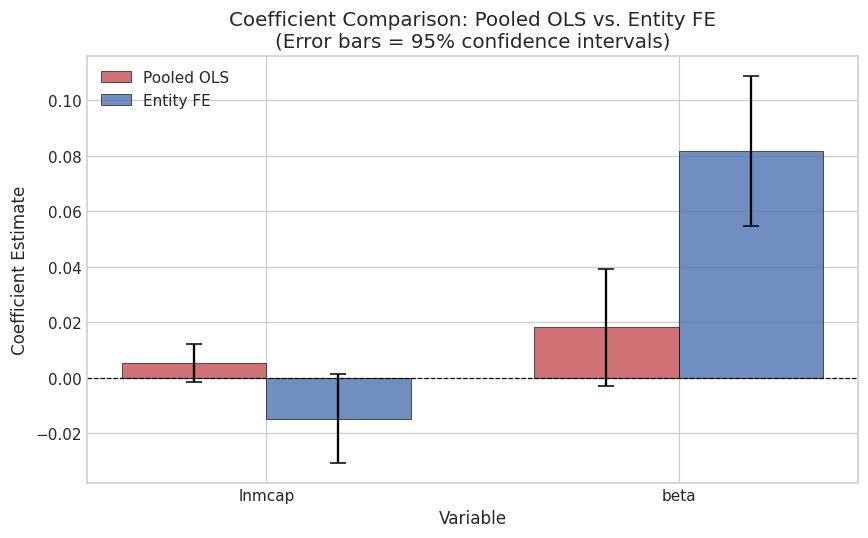

In [17]:
# Chart 7: Coefficient comparison — Pooled OLS vs Entity FE
fig, ax = plt.subplots(figsize=(8, 5))

variables = ['lnmcap', 'beta']
x_positions = np.arange(len(variables))
bar_width = 0.35

pooled_coefs = [pooled_lnmcap_coef, pooled_beta_coef]
entity_fe_coefs = [entity_fe_lnmcap_coef, entity_fe_beta_coef]

# Confidence intervals for error bars
pooled_lnmcap_ci = pooled_ols_model.conf_int().loc['lnmcap']
pooled_beta_ci = pooled_ols_model.conf_int().loc['beta']
pooled_errors = [
    [pooled_lnmcap_coef - pooled_lnmcap_ci[0], pooled_beta_coef - pooled_beta_ci[0]],
    [pooled_lnmcap_ci[1] - pooled_lnmcap_coef, pooled_beta_ci[1] - pooled_beta_coef]
]

fe_ci = entity_fe_results.conf_int()
fe_errors = [
    [entity_fe_lnmcap_coef - fe_ci.loc['lnmcap', 'lower'],
     entity_fe_beta_coef - fe_ci.loc['beta', 'lower']],
    [fe_ci.loc['lnmcap', 'upper'] - entity_fe_lnmcap_coef,
     fe_ci.loc['beta', 'upper'] - entity_fe_beta_coef]
]

ax.bar(x_positions - bar_width/2, pooled_coefs, bar_width,
       yerr=pooled_errors, capsize=5,
       label='Pooled OLS', color=COLOR_POOLED, alpha=0.8, edgecolor='black', linewidth=0.5)
ax.bar(x_positions + bar_width/2, entity_fe_coefs, bar_width,
       yerr=fe_errors, capsize=5,
       label='Entity FE', color=COLOR_ENTITY_FE, alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Variable')
ax.set_ylabel('Coefficient Estimate')
ax.set_title('Coefficient Comparison: Pooled OLS vs. Entity FE\n(Error bars = 95% confidence intervals)')
ax.set_xticks(x_positions)
ax.set_xticklabels(variables)
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig(DEMO_DIR / 'fe_demo_coef_comparison_2model.png', dpi=150, bbox_inches='tight')
print("Saved: fe_demo_coef_comparison_2model.png")
plt.show()

### What Changed?

Compare the `lnmcap` coefficient between Pooled OLS and Entity FE:

- **Pooled OLS** includes between-entity variation — it reflects *which* REITs are bigger
- **Entity FE** uses only within-entity variation — it reflects what happens *when a given REIT changes size*

The difference between these two coefficients is evidence of **omitted variable bias** in the Pooled OLS model.

---

## Section 6: Model 3 — Two-Way Fixed Effects (Entity + Time)

Entity FE controls for REIT-specific characteristics, but what about market-wide shocks that affect *all* REITs in a given year (e.g., the 2008 financial crisis, the 2020 pandemic)?

Two-Way FE adds **time fixed effects** ($\gamma_t$) on top of entity fixed effects:

$$\text{ret12}_{it} = \alpha_i + \gamma_t + \beta_1 \cdot \text{lnmcap}_{it} + \beta_2 \cdot \text{beta}_{it} + \varepsilon_{it}$$

This absorbs both entity-specific *and* year-specific unobserved factors.

### Visualizing What a Time Fixed Effect Does

A **time fixed effect** is the year-version of the same idea. Instead of subtracting each firm's own average, it subtracts the average level for each year. For year $t$, the time-demeaned version is:

$$y_{it} - \bar{y}_t$$

This removes the part of the outcome that is common to all firms in that year, such as a boom, recession, credit shock, or pandemic effect.

Saved: fe_demo_time_demeaning_lines.png


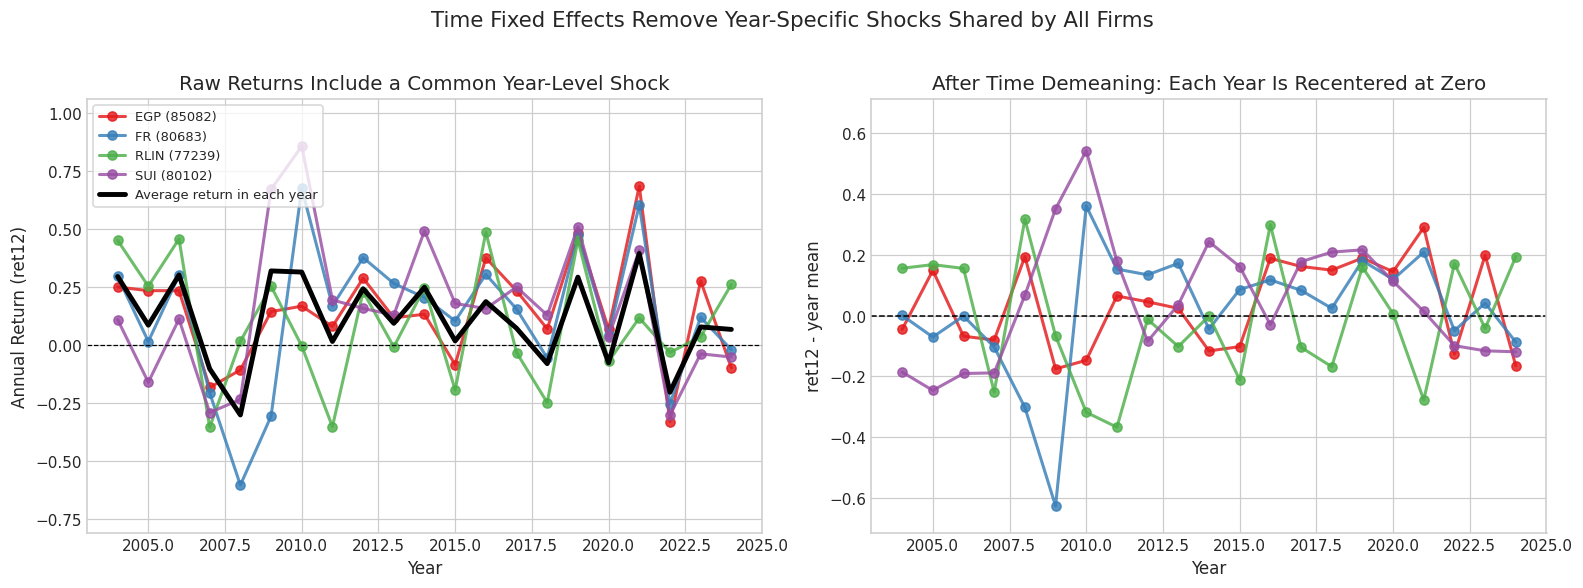

In [18]:
# Chart 7b: Time fixed effects as year-specific recentering
year_means = df.groupby('year')['ret12'].mean()
time_demo = df[df['permno'].isin(entity_demo_reits)].copy()
time_demo['year_mean_ret12'] = time_demo['year'].map(year_means)
time_demo['time_demeaned_ret12'] = time_demo['ret12'] - time_demo['year_mean_ret12']

raw_ret_min = min(time_demo['ret12'].min(), year_means.min())
raw_ret_max = max(time_demo['ret12'].max(), year_means.max())
raw_ret_padding = max(0.06, (raw_ret_max - raw_ret_min) * 0.14)
time_demeaned_abs = time_demo['time_demeaned_ret12'].abs().max()
time_demeaned_padding = max(0.05, time_demeaned_abs * 0.14)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2), sharex=True)

for i, reit_id in enumerate(entity_demo_reits):
    firm_subset = time_demo[time_demo['permno'] == reit_id].sort_values('year')
    firm_color = highlight_colors[i % len(highlight_colors)]
    firm_label = f"{firm_labels[reit_id]} ({reit_id})"

    axes[0].plot(
        firm_subset['year'],
        firm_subset['ret12'],
        marker='o',
        markersize=6,
        linewidth=2.0,
        color=firm_color,
        alpha=0.82,
        label=firm_label
    )
    axes[1].plot(
        firm_subset['year'],
        firm_subset['time_demeaned_ret12'],
        marker='o',
        markersize=6,
        linewidth=2.0,
        color=firm_color,
        alpha=0.82,
        label=firm_label
    )

axes[0].plot(
    year_means.index,
    year_means.values,
    color='black',
    linewidth=3.2,
    label='Average return in each year'
 )
axes[0].set_title('Raw Returns Include a Common Year-Level Shock')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Annual Return (ret12)')
axes[0].set_ylim(raw_ret_min - raw_ret_padding, raw_ret_max + raw_ret_padding)
axes[0].legend(loc='upper left', fontsize=8.5, frameon=True)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('After Time Demeaning: Each Year Is Recentered at Zero')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('ret12 - year mean')
axes[1].set_ylim(-(time_demeaned_abs + time_demeaned_padding), time_demeaned_abs + time_demeaned_padding)

fig.suptitle('Time Fixed Effects Remove Year-Specific Shocks Shared by All Firms', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(DEMO_DIR / 'fe_demo_time_demeaning_lines.png', dpi=150, bbox_inches='tight')
print('Saved: fe_demo_time_demeaning_lines.png')
plt.show()

The black line in the left panel is the part that time fixed effects absorb: a common yearly shift that pushes all firms up or down together. Once that year-level average is subtracted, the right panel shows how each firm's return moves **relative to what was typical in that year**.

Saved: fe_demo_twoway_fe_synthetic_diagram.png


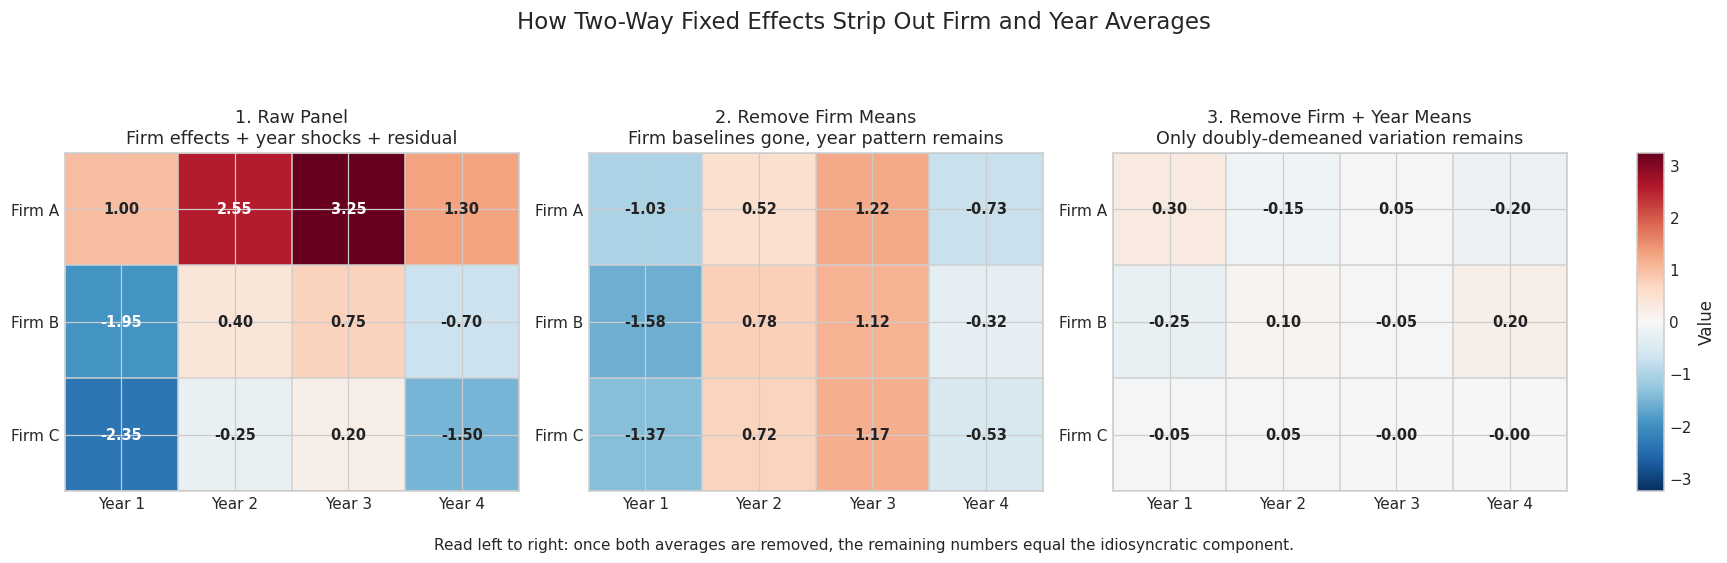

In [19]:
# Chart 7c: Synthetic two-way fixed effects decomposition
synthetic_firms = ['Firm A', 'Firm B', 'Firm C']
synthetic_years = ['Year 1', 'Year 2', 'Year 3', 'Year 4']
firm_effects = np.array([1.8, -0.6, -1.2])
year_effects = np.array([-1.1, 0.9, 1.4, -0.3])
idiosyncratic_component = np.array([
    [0.30, -0.15, 0.05, -0.20],
    [-0.25, 0.10, -0.05, 0.20],
    [-0.05, 0.05, 0.00, 0.00]
 ])

raw_outcome = firm_effects[:, None] + year_effects[None, :] + idiosyncratic_component
entity_demeaned = raw_outcome - raw_outcome.mean(axis=1, keepdims=True)
two_way_demeaned = (
    raw_outcome
    - raw_outcome.mean(axis=1, keepdims=True)
    - raw_outcome.mean(axis=0, keepdims=True)
    + raw_outcome.mean()
 )

plot_matrices = [raw_outcome, entity_demeaned, two_way_demeaned]
plot_titles = [
    '1. Raw Panel',
    '2. Remove Firm Means',
    '3. Remove Firm + Year Means'
 ]
plot_subtitles = [
    'Firm effects + year shocks + residual',
    'Firm baselines gone, year pattern remains',
    'Only doubly-demeaned variation remains'
 ]

max_abs_value = np.abs(np.concatenate([matrix.ravel() for matrix in plot_matrices])).max()
fig, axes = plt.subplots(
    1, 4,
    figsize=(15.8, 4.8),
    gridspec_kw={'width_ratios': [1, 1, 1, 0.06]}
 )
heat_axes = axes[:3]
cbar_ax = axes[3]

for ax, matrix, title, subtitle in zip(heat_axes, plot_matrices, plot_titles, plot_subtitles):
    image = ax.imshow(matrix, cmap='RdBu_r', vmin=-max_abs_value, vmax=max_abs_value, aspect='auto')
    ax.set_xticks(np.arange(len(synthetic_years)))
    ax.set_xticklabels(synthetic_years)
    ax.set_yticks(np.arange(len(synthetic_firms)))
    ax.set_yticklabels(synthetic_firms)
    ax.set_title(f"{title}\n{subtitle}", fontsize=11.5)

    ax.set_xticks(np.arange(-0.5, len(synthetic_years), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(synthetic_firms), 1), minor=True)
    ax.grid(which='minor', color='#d0d0d0', linewidth=1.0)
    ax.tick_params(which='minor', bottom=False, left=False)
    ax.tick_params(axis='both', length=0)

    for row_idx in range(matrix.shape[0]):
        for col_idx in range(matrix.shape[1]):
            cell_value = matrix[row_idx, col_idx]
            text_color = 'white' if abs(cell_value) > max_abs_value * 0.55 else '#222222'
            ax.text(
                col_idx,
                row_idx,
                f"{cell_value:.2f}",
                ha='center',
                va='center',
                color=text_color,
                fontsize=9.5,
                fontweight='semibold'
            )

colorbar = fig.colorbar(image, cax=cbar_ax)
colorbar.set_label('Value', rotation=90)

fig.suptitle('How Two-Way Fixed Effects Strip Out Firm and Year Averages', y=1.03, fontsize=15)
fig.text(
    0.5,
    0.01,
    'Read left to right: once both averages are removed, the remaining numbers equal the idiosyncratic component.',
    ha='center',
    fontsize=10
 )
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(DEMO_DIR / 'fe_demo_twoway_fe_synthetic_diagram.png', dpi=150, bbox_inches='tight')
print('Saved: fe_demo_twoway_fe_synthetic_diagram.png')
plt.show()

The synthetic diagram makes the algebra visible. The first panel contains three ingredients mixed together: firm baselines, year shocks, and a leftover idiosyncratic component. After removing firm means, a clear year pattern is still visible. After removing both firm and year means, only the doubly-demeaned variation remains. That remaining variation is what identifies the slopes in a two-way fixed-effects model.

In [20]:
# Model 3: Two-Way Fixed Effects (Entity + Time)
y_panel_return = panel_df['ret12']
X_panel_predictors = panel_df[['lnmcap', 'beta']]

# entity_effects=True AND time_effects=True for two-way FE
twoway_fe_model = PanelOLS(
    y_panel_return, X_panel_predictors,
    entity_effects=True, time_effects=True
)
twoway_fe_results = twoway_fe_model.fit(cov_type='clustered', cluster_entity=True)

print("=" * 60)
print("MODEL 3: TWO-WAY FIXED EFFECTS (Entity + Time)")
print("=" * 60)
print(twoway_fe_results.summary.tables[1])

# Extract key results
twoway_lnmcap_coef = twoway_fe_results.params['lnmcap']
twoway_beta_coef = twoway_fe_results.params['beta']
twoway_r_squared = twoway_fe_results.rsquared

print(f"\nKey Results:")
print(f"  lnmcap coefficient: {twoway_lnmcap_coef:.4f}")
print(f"  beta coefficient:   {twoway_beta_coef:.4f}")
print(f"  R-squared (within): {twoway_r_squared:.4f}")

MODEL 3: TWO-WAY FIXED EFFECTS (Entity + Time)
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
lnmcap         0.0207     0.0151     1.3700     0.1708     -0.0090      0.0504
beta           0.1028     0.0213     4.8176     0.0000      0.0609      0.1446

Key Results:
  lnmcap coefficient: 0.0207
  beta coefficient:   0.1028
  R-squared (within): 0.0200


---

## Section 7: F-Test — Are the Fixed Effects Significant?

We need to test whether the entity fixed effects are **jointly significant**. The null hypothesis is:

$$H_0: \alpha_1 = \alpha_2 = \ldots = \alpha_N = 0$$

A large F-statistic means the entity effects are jointly significant — we **need** them.

In [21]:
# F-test for joint significance of entity fixed effects
entity_f_stat = entity_fe_results.f_statistic

print("=" * 60)
print("F-TEST: Are Entity Fixed Effects Jointly Significant?")
print("=" * 60)
print(f"  F-statistic:  {entity_f_stat.stat:.2f}")
print(f"  p-value:      {entity_f_stat.pval:.6f}")
print(f"  df (num):     {entity_f_stat.df:.0f}")
print(f"  df (denom):   {entity_f_stat.df_denom:.0f}")

if entity_f_stat.pval < 0.05:
    print(f"\n  CONCLUSION: Reject H0 at 5% level.")
    print(f"  The entity fixed effects ARE jointly significant.")
    print(f"  REITs have meaningfully different baseline characteristics.")
    print(f"  Pooled OLS is inappropriate for this data.")
else:
    print(f"\n  CONCLUSION: Fail to reject H0.")
    print(f"  Entity fixed effects may not be needed.")

F-TEST: Are Entity Fixed Effects Jointly Significant?
  F-statistic:  17.19
  p-value:      0.000000
  df (num):     2
  df (denom):   2147

  CONCLUSION: Reject H0 at 5% level.
  The entity fixed effects ARE jointly significant.
  REITs have meaningfully different baseline characteristics.
  Pooled OLS is inappropriate for this data.


---

## Section 8: Three-Model Comparison Table

Now let's put all three models side by side to see how the coefficients change as we add more controls for unobserved heterogeneity.

In [22]:
# Build comparison table
comparison_data = {
    'Pooled OLS': {
        'lnmcap': f"{pooled_lnmcap_coef:.4f}",
        'beta': f"{pooled_beta_coef:.4f}",
        'R-squared': f"{pooled_r_squared:.4f}",
        'Entity FE': 'No',
        'Time FE': 'No',
        'Observations': str(int(pooled_ols_model.nobs)),
    },
    'Entity FE': {
        'lnmcap': f"{entity_fe_lnmcap_coef:.4f}",
        'beta': f"{entity_fe_beta_coef:.4f}",
        'R-squared': f"{entity_fe_r_squared:.4f}",
        'Entity FE': 'Yes',
        'Time FE': 'No',
        'Observations': str(entity_fe_results.nobs),
    },
    'Two-Way FE': {
        'lnmcap': f"{twoway_lnmcap_coef:.4f}",
        'beta': f"{twoway_beta_coef:.4f}",
        'R-squared': f"{twoway_r_squared:.4f}",
        'Entity FE': 'Yes',
        'Time FE': 'Yes',
        'Observations': str(twoway_fe_results.nobs),
    }
}

comparison_table = pd.DataFrame(comparison_data)
print("=" * 60)
print("THREE-MODEL COMPARISON TABLE")
print("=" * 60)
print(comparison_table.to_string())

THREE-MODEL COMPARISON TABLE
             Pooled OLS Entity FE Two-Way FE
lnmcap           0.0053   -0.0149     0.0207
beta             0.0181    0.0819     0.1028
R-squared        0.0019    0.0158     0.0200
Entity FE            No       Yes        Yes
Time FE              No        No        Yes
Observations       2387      2387       2387


---

## Section 9: Visual Summary

Saved: fe_demo_coef_comparison_3model.png


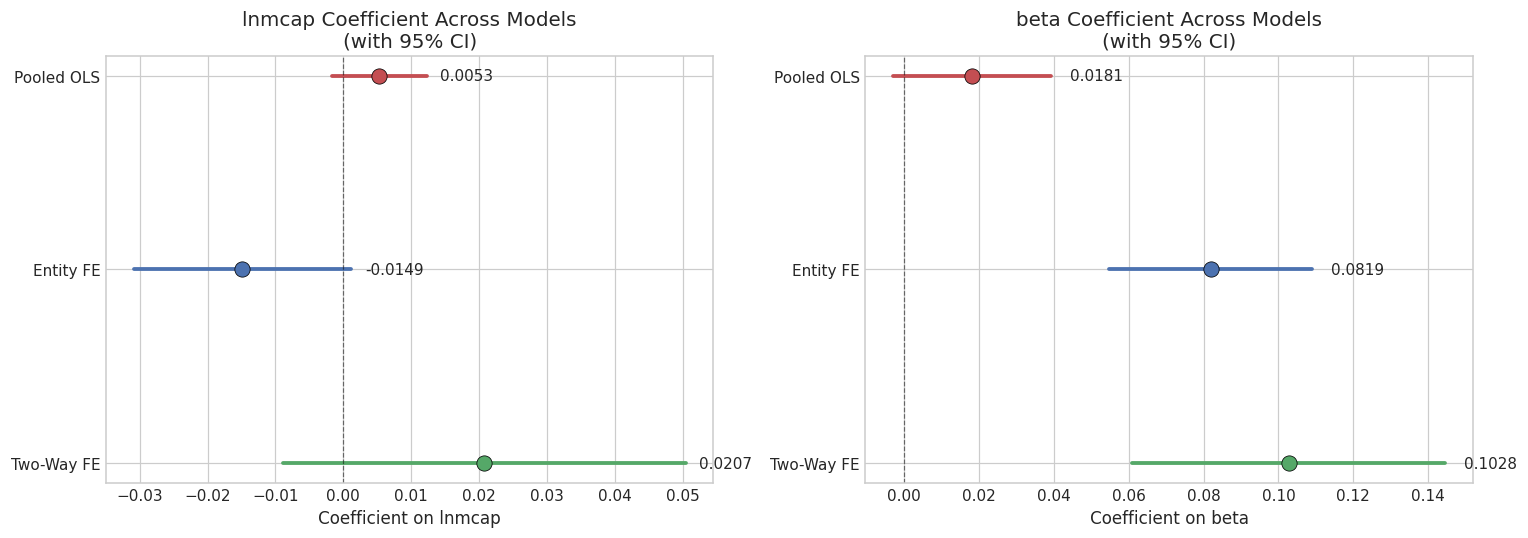

In [23]:
# Chart 8: Three-model coefficient comparison (dot plot with CIs)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Pooled OLS', 'Entity FE', 'Two-Way FE']
colors = [COLOR_POOLED, COLOR_ENTITY_FE, COLOR_TWOWAY_FE]
y_positions = [2, 1, 0]

# --- Left panel: lnmcap coefficient ---
lnmcap_coefs = [pooled_lnmcap_coef, entity_fe_lnmcap_coef, twoway_lnmcap_coef]

pooled_ci_lnmcap = pooled_ols_model.conf_int().loc['lnmcap']
fe_ci_lnmcap = entity_fe_results.conf_int().loc['lnmcap']
tw_ci_lnmcap = twoway_fe_results.conf_int().loc['lnmcap']

lnmcap_lower = [pooled_ci_lnmcap[0], fe_ci_lnmcap['lower'], tw_ci_lnmcap['lower']]
lnmcap_upper = [pooled_ci_lnmcap[1], fe_ci_lnmcap['upper'], tw_ci_lnmcap['upper']]

for i in range(3):
    axes[0].plot([lnmcap_lower[i], lnmcap_upper[i]], [y_positions[i], y_positions[i]],
                 color=colors[i], linewidth=2.5, solid_capstyle='round')
    axes[0].scatter([lnmcap_coefs[i]], [y_positions[i]],
                    color=colors[i], s=100, zorder=5, edgecolors='black', linewidth=0.5)
    axes[0].text(lnmcap_upper[i] + 0.002, y_positions[i],
                 f"{lnmcap_coefs[i]:.4f}", va='center', fontsize=10)

axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(models)
axes[0].set_xlabel('Coefficient on lnmcap')
axes[0].set_title('lnmcap Coefficient Across Models\n(with 95% CI)')

# --- Right panel: beta coefficient ---
beta_coefs = [pooled_beta_coef, entity_fe_beta_coef, twoway_beta_coef]

pooled_ci_beta = pooled_ols_model.conf_int().loc['beta']
fe_ci_beta = entity_fe_results.conf_int().loc['beta']
tw_ci_beta = twoway_fe_results.conf_int().loc['beta']

beta_lower = [pooled_ci_beta[0], fe_ci_beta['lower'], tw_ci_beta['lower']]
beta_upper = [pooled_ci_beta[1], fe_ci_beta['upper'], tw_ci_beta['upper']]

for i in range(3):
    axes[1].plot([beta_lower[i], beta_upper[i]], [y_positions[i], y_positions[i]],
                 color=colors[i], linewidth=2.5, solid_capstyle='round')
    axes[1].scatter([beta_coefs[i]], [y_positions[i]],
                    color=colors[i], s=100, zorder=5, edgecolors='black', linewidth=0.5)
    axes[1].text(beta_upper[i] + 0.005, y_positions[i],
                 f"{beta_coefs[i]:.4f}", va='center', fontsize=10)

axes[1].axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[1].set_yticks(y_positions)
axes[1].set_yticklabels(models)
axes[1].set_xlabel('Coefficient on beta')
axes[1].set_title('beta Coefficient Across Models\n(with 95% CI)')

plt.tight_layout()
plt.savefig(DEMO_DIR / 'fe_demo_coef_comparison_3model.png', dpi=150, bbox_inches='tight')
print("Saved: fe_demo_coef_comparison_3model.png")
plt.show()

Saved: fe_demo_r_squared_comparison.png


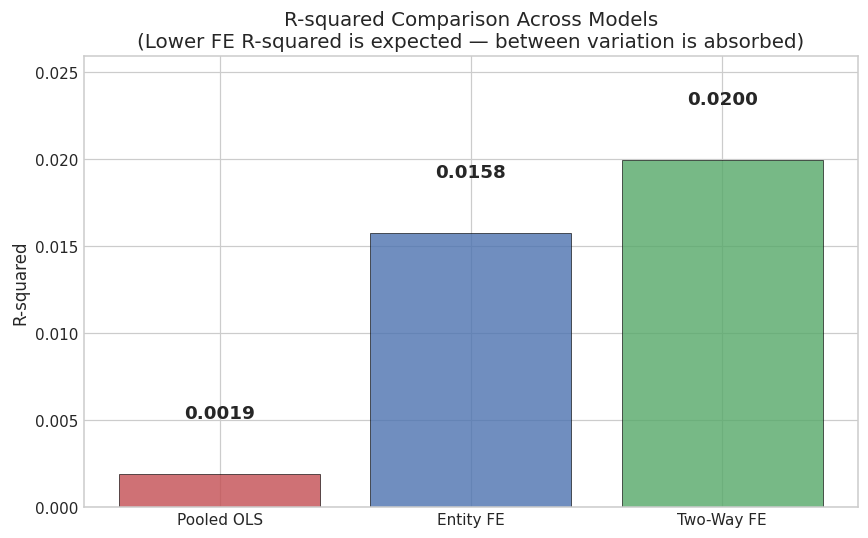

In [24]:
# Chart 9: R-squared comparison across models
fig, ax = plt.subplots(figsize=(8, 5))

model_names = ['Pooled OLS', 'Entity FE', 'Two-Way FE']
r_squared_values = [pooled_r_squared, entity_fe_r_squared, twoway_r_squared]
bar_colors = [COLOR_POOLED, COLOR_ENTITY_FE, COLOR_TWOWAY_FE]

bars = ax.bar(model_names, r_squared_values, color=bar_colors, alpha=0.8,
              edgecolor='black', linewidth=0.5)

# Add value labels on each bar
for bar, r2 in zip(bars, r_squared_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{r2:.4f}", ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('R-squared')
ax.set_title('R-squared Comparison Across Models\n'
             '(Lower FE R-squared is expected — between variation is absorbed)')
ax.set_ylim(0, max(r_squared_values) * 1.3)

plt.tight_layout()
plt.savefig(DEMO_DIR / 'fe_demo_r_squared_comparison.png', dpi=150, bbox_inches='tight')
print("Saved: fe_demo_r_squared_comparison.png")
plt.show()

### Why Does R-squared Drop?

You might expect that adding more controls would **increase** R-squared. But FE R-squared often **drops** compared to Pooled OLS. Why?

- **Pooled OLS R-squared** reflects how well the model explains *total* variation (between + within)
- **FE R-squared** reflects how well the model explains *within-entity* variation only (after demeaning)

The between-entity variation is **absorbed by the fixed effects** — it is no longer in the residual or the "explained" part that R-squared measures. A lower R-squared with FE does **not** mean a worse model. The goal is **unbiased coefficients**, not high R-squared.

Saved: fe_demo_residual_distributions.png


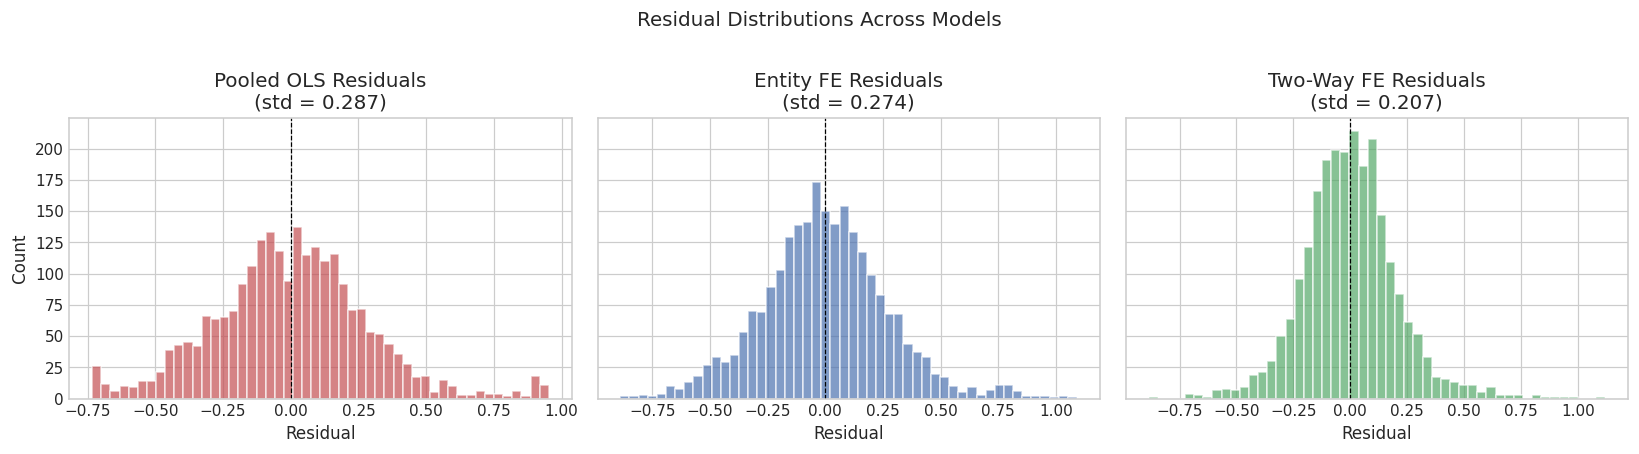

In [25]:
# Chart 10: Residual distributions across models
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# Pooled OLS residuals
pooled_residuals = pooled_ols_model.resid
axes[0].hist(pooled_residuals, bins=50, color=COLOR_POOLED, alpha=0.7, edgecolor='white')
axes[0].set_title(f'Pooled OLS Residuals\n(std = {pooled_residuals.std():.3f})')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Count')
axes[0].axvline(x=0, color='black', linewidth=0.8, linestyle='--')

# Entity FE residuals
entity_fe_residuals = entity_fe_results.resids
axes[1].hist(entity_fe_residuals, bins=50, color=COLOR_ENTITY_FE, alpha=0.7, edgecolor='white')
axes[1].set_title(f'Entity FE Residuals\n(std = {entity_fe_residuals.std():.3f})')
axes[1].set_xlabel('Residual')
axes[1].axvline(x=0, color='black', linewidth=0.8, linestyle='--')

# Two-Way FE residuals
twoway_fe_residuals = twoway_fe_results.resids
axes[2].hist(twoway_fe_residuals, bins=50, color=COLOR_TWOWAY_FE, alpha=0.7, edgecolor='white')
axes[2].set_title(f'Two-Way FE Residuals\n(std = {twoway_fe_residuals.std():.3f})')
axes[2].set_xlabel('Residual')
axes[2].axvline(x=0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Residual Distributions Across Models', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(DEMO_DIR / 'fe_demo_residual_distributions.png', dpi=150, bbox_inches='tight')
print("Saved: fe_demo_residual_distributions.png")
plt.show()

---

## Section 10: Key Takeaways

1. **Pooled OLS is biased** when unobserved entity characteristics are correlated with predictors. The coefficients mix between-entity and within-entity variation.

2. **Entity Fixed Effects** controls for all time-invariant entity characteristics by giving each REIT its own intercept. Coefficients now reflect *within-entity* changes only.

3. **Two-Way Fixed Effects** adds time dummies to also absorb year-specific shocks (e.g., 2008 crisis, 2020 pandemic) that affect all entities simultaneously.

4. **The F-test** tells us whether the entity fixed effects are jointly significant. A significant F-test means Pooled OLS is inappropriate.

5. **R-squared may drop** from Pooled OLS to FE — this is expected and does not indicate a worse model. Between-entity variation is absorbed, not lost.

6. **Key Python steps**:

   - Set MultiIndex: `df.set_index(['permno', 'year']).sort_index()`
   - Entity FE: `PanelOLS(y, X, entity_effects=True)`
   - Two-Way FE: `PanelOLS(y, X, entity_effects=True, time_effects=True)`
   - Clustered SEs: `.fit(cov_type='clustered', cluster_entity=True)`

---

**Next week:** We use Fixed Effects as a building block for **Difference-in-Differences** — the gold standard for evaluating policy changes and natural experiments.